In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

In [2]:
clean_metadata_df = pd.read_csv("../data/processed/clean_metadata.csv")

In [3]:
# Train-test split at the metadata level 

train_meta, test_meta = train_test_split(clean_metadata_df, test_size=0.2, random_state=42, stratify=clean_metadata_df["Scenario"])

In [4]:
print(f"Number of train files: {len(train_meta)}")
print(f"Number of test files: {len(test_meta)}")

print("\nTrain Scenario distribution:")
print(train_meta["Scenario"].value_counts())

print("\nTest Scenario distribution:")
print(test_meta["Scenario"].value_counts())

Number of train files: 1534
Number of test files: 384

Train Scenario distribution:
Scenario
attack_rwa    480
attack_rwc    479
attack_rwb    479
baseline       96
Name: count, dtype: int64

Test Scenario distribution:
Scenario
attack_rwb    120
attack_rwc    120
attack_rwa    120
baseline       24
Name: count, dtype: int64


In [5]:
#Function to read each CSV in the given metadata rows (data_file_processed) and combine them into a single dataframe:

def load_and_combine(meta_df):

    all_dfs = []
    for _, row in meta_df.iterrows():
        df = pd.read_csv(row["data_file_processed"])
        all_dfs.append(df)
    return pd.concat(all_dfs, ignore_index= True)

   

In [6]:
train_df = load_and_combine(train_meta)
test_df = load_and_combine(test_meta)

In [7]:
print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")

train shape: (923468, 28)
test shape: (231168, 28)


In [8]:
print(f"Train label distribution: {train_df["label_binary"].value_counts()}")
print(f"\nTest label distribution: {test_df["label_binary"].value_counts()}")


Train label distribution: label_binary
0    492068
1    431400
Name: count, dtype: int64

Test label distribution: label_binary
0    123168
1    108000
Name: count, dtype: int64


In [9]:
FEATURE_COLS = [col for col in train_df.columns if col not in ["result_label", "label_binary"]]

X_train = train_df[FEATURE_COLS]
y_train = train_df["label_binary"]

X_test = test_df[FEATURE_COLS]
y_test = test_df["label_binary"]


In [10]:
# Column names like "Q_B_I[0](1)" or "AttitudeError[1](rad)" contain square brackets (`[`, `]`).
# XGBoost's internal mechanism treats these characters as special symbols (they conflict with its "feature interaction / split" syntax),
# which causes a "ValueError" during "model.fit()".
# To fix it, we write a small function that replaces `[`, `]`, `<`, `(`, `)` characters in column names with `_` before feeding the data into the model.
import re

def clean_column_names(columns):
    cleaned = [re.sub(r"[\[\]<>()]" , "_", col) for col in columns]
    return cleaned 

X_train.columns = clean_column_names(X_train.columns)
X_test.columns = clean_column_names(X_test.columns)

print(X_train.columns.tolist())
   

['Q_B_I_0__1_', 'Q_B_I_1__1_', 'Q_B_I_2__1_', 'Q_B_I_3__1_', 'AttitudeError_0__rad_', 'AttitudeError_1__rad_', 'AttitudeError_2__rad_', 'AngVel_B_I_0__rad/sec_', 'AngVel_B_I_1__rad/sec_', 'AngVel_B_I_2__rad/sec_', 'AngVelMag_B_I_rad/sec_', 'SensedWheelSpeed__RWA_A_rad/sec_', 'SensedWheelSpeed__RWA_B_rad/sec_', 'SensedWheelSpeed__RWA_C_rad/sec_', 'WheelCmd__RWA_A_N*m_', 'WheelCmd__RWA_B_N*m_', 'WheelCmd__RWA_C_N*m_', 'DesiredWheelCommand_0__N*m_', 'DesiredWheelCommand_1__N*m_', 'DesiredWheelCommand_2__N*m_', 'TotalTorqueRodCommand_0__A*m^2_', 'TotalTorqueRodCommand_1__A*m^2_', 'TotalTorqueRodCommand_2__A*m^2_', 'BField_B__TAM_0__T_', 'BField_B__TAM_1__T_', 'BField_B__TAM_2__T_']


In [11]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [12]:
#Predictions
y_pred = model.predict(X_test)

#Metrics
print("Accuracy:" , accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))


Accuracy: 0.9955486918604651
Precision: 0.9965372225368326
Recall: 0.9939259259259259
F1 Score: 0.9952298613461155

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    123168
           1       1.00      0.99      1.00    108000

    accuracy                           1.00    231168
   macro avg       1.00      1.00      1.00    231168
weighted avg       1.00      1.00      1.00    231168



In [13]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(10))

TotalTorqueRodCommand_2__A*m^2_     0.577986
SensedWheelSpeed__RWA_C_rad/sec_    0.080539
TotalTorqueRodCommand_0__A*m^2_     0.069875
TotalTorqueRodCommand_1__A*m^2_     0.066487
SensedWheelSpeed__RWA_B_rad/sec_    0.053464
AngVelMag_B_I_rad/sec_              0.036585
AngVel_B_I_1__rad/sec_              0.016557
SensedWheelSpeed__RWA_A_rad/sec_    0.016554
AngVel_B_I_2__rad/sec_              0.011172
Q_B_I_3__1_                         0.010088
dtype: float32


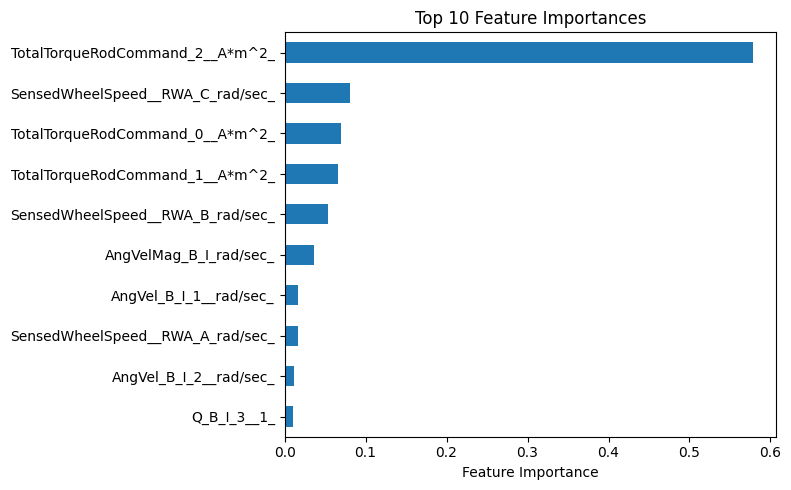

In [14]:
plt.figure(figsize=(8, 5))
importances.head(10).sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [15]:
# Overfitting check

from sklearn.metrics import roc_auc_score

y_train_pred = model.predict(X_train)
y_train_proba = model.predict_proba(X_train)[:, 1]

y_test_pred = y_pred
y_test_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": (accuracy_score(y_train, y_train_pred),  accuracy_score(y_test, y_test_pred)),
    "Precision": (precision_score(y_train, y_train_pred),  precision_score(y_test, y_test_pred)),
    "Recall": (recall_score(y_train, y_train_pred),  recall_score(y_test, y_test_pred)),
    "F1 Score": (f1_score(y_train, y_train_pred),  f1_score(y_test, y_test_pred)),
    "AUC": (roc_auc_score(y_train, y_train_proba),  roc_auc_score(y_test, y_test_proba)),
}

results_table = pd.DataFrame({
    "Train": [v[0] for v in metrics.values()],
    "Test": [v[1] for v in metrics.values()],
}, index=metrics.keys())

results_table["Difference"] = results_table["Train"] - results_table["Test"]
results_table.round(4)



,Train,Test,Difference
Accuracy,0.9997,0.9955,0.0042
Precision,0.9996,0.9965,0.0030
Recall,0.9999,0.9939,0.0060
F1 Score,0.9997,0.9952,0.0045
AUC,1.0000,0.9998,0.0002


## Overfitting vs. Feature Dominance

The train/test difference across all metrics is well below 1-2% (Accuracy: 0.0042, Precision: 0.0030, Recall: 0.0060, F1: 0.0045, AUC: 0.0002). This confirms the model is **not overfitting**, it generalizes well to unseen files, since train and test performance are nearly identical.

However, this is a separate issue from overfitting. The feature importance results show that a single feature, `TotalTorqueRodCommand[2]`, alone accounts for ~58% of total importance, and together with `TotalTorqueRodCommand[0,1]` and `SensedWheelSpeed__RWA_B/C`, the top 5 features account for ~85% of total importance. This means the model generalizes well, but it does so by leaning heavily on a handful of very dominant features rather than learning from the broader signal across all 26 features.

In other words: **the model is not overfit, but it is overly reliant on a few "primary affected" columns**, the ones the attack directly injects into or manipulates. This aligns with a note left by the dataset provider:

> "Also try training without the primary affected columns (the ones that are directly affected by the attack)."

Based on this suggestion, together with the observed heavy reliance on a few dominant features, it was decided to remove these primary affected columns (`SensedWheelSpeed__RWA_A/B/C` and `TotalTorqueRodCommand[0,1,2]`) and retrain the model without them, to check whether the remaining 20 features still carry enough signal to detect attacks on their own.

# Retraining the Model Without Primary Affected Columns

In [ ]:
PRIMARY_AFFECTED_COLUMNS = [
    "SensedWheelSpeed__RWA_A(rad/sec)", "SensedWheelSpeed__RWA_B(rad/sec)", "SensedWheelSpeed__RWA_C(rad/sec)",
    "TotalTorqueRodCommand[0](A*m^2)", "TotalTorqueRodCommand[1](A*m^2)", "TotalTorqueRodCommand[2](A*m^2)"
]

PRIMARY_AFFECTED_CLEANED = clean_column_names(PRIMARY_AFFECTED_COLUMNS) #cleaned again to avoid format issues in XGBoost

X_train_no_primary = X_train.drop(columns=PRIMARY_AFFECTED_CLEANED)
X_test_no_primary = X_test.drop(columns = PRIMARY_AFFECTED_CLEANED)

model_no_primary = XGBClassifier(
    n_estimators =200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model_no_primary.fit(X_train_no_primary, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
#Predictions
y_pred_no_primary = model_no_primary.predict(X_test_no_primary)

#Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_no_primary))
print("Precision:", precision_score(y_test, y_pred_no_primary))
print("Recall:", recall_score(y_test, y_pred_no_primary))
print("F1 Score:", f1_score(y_test, y_pred_no_primary))

print(classification_report(y_test, y_pred_no_primary))

Accuracy: 0.9602669919712071
Precision: 0.9406701807900534
Recall: 0.9765462962962963
F1 Score: 0.9582725707458238
              precision    recall  f1-score   support

           0       0.98      0.95      0.96    123168
           1       0.94      0.98      0.96    108000

    accuracy                           0.96    231168
   macro avg       0.96      0.96      0.96    231168
weighted avg       0.96      0.96      0.96    231168



In [18]:
importances_no_primary = pd.Series(model_no_primary.feature_importances_, index=X_train_no_primary.columns)
importances_no_primary = importances_no_primary.sort_values(ascending=False)
print(importances_no_primary.head(10))

WheelCmd__RWA_C_N*m_           0.100696
DesiredWheelCommand_1__N*m_    0.083365
WheelCmd__RWA_B_N*m_           0.078272
Q_B_I_3__1_                    0.071633
BField_B__TAM_2__T_            0.064515
AngVelMag_B_I_rad/sec_         0.059806
BField_B__TAM_1__T_            0.055621
Q_B_I_2__1_                    0.054109
DesiredWheelCommand_2__N*m_    0.052698
Q_B_I_1__1_                    0.051776
dtype: float32


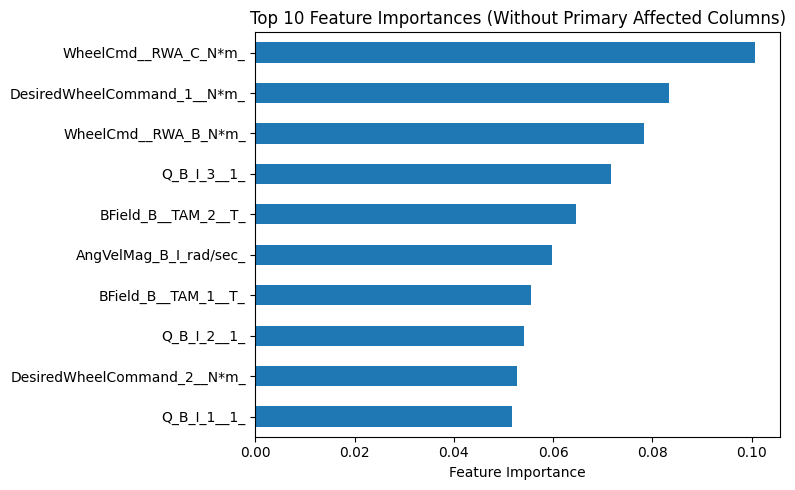

In [19]:
plt.figure(figsize=(8, 5))
importances_no_primary.head(10).sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Without Primary Affected Columns)")
plt.tight_layout()
plt.show()

In [20]:
# Overfitting check - No Primary Affected Columns

y_train_pred_no_primary = model_no_primary.predict(X_train_no_primary)
y_train_proba_no_primary = model_no_primary.predict_proba(X_train_no_primary)[:, 1]

y_test_pred_no_primary = model_no_primary.predict(X_test_no_primary)
y_test_proba_no_primary = model_no_primary.predict_proba(X_test_no_primary)[:, 1]

metrics_no_primary = {
    "Accuracy": (accuracy_score(y_train, y_train_pred_no_primary), accuracy_score(y_test, y_test_pred_no_primary)),
    "Precision": (precision_score(y_train, y_train_pred_no_primary), precision_score(y_test, y_test_pred_no_primary)),
    "Recall": (recall_score(y_train, y_train_pred_no_primary), recall_score(y_test, y_test_pred_no_primary)),
    "F1 Score": (f1_score(y_train, y_train_pred_no_primary), f1_score(y_test, y_test_pred_no_primary)),
    "AUC": (roc_auc_score(y_train, y_train_proba_no_primary), roc_auc_score(y_test, y_test_proba_no_primary)),
}

results_table_no_primary = pd.DataFrame({
    "Train": [v[0] for v in metrics_no_primary.values()],
    "Test": [v[1] for v in metrics_no_primary.values()],
}, index=metrics_no_primary.keys())

results_table_no_primary["Difference"] = results_table_no_primary["Train"] - results_table_no_primary["Test"]
results_table_no_primary.round(4)

,Train,Test,Difference
Accuracy,0.9643,0.9603,0.0041
Precision,0.9429,0.9407,0.0022
Recall,0.9832,0.9765,0.0067
F1 Score,0.9626,0.9583,0.0044
AUC,0.9888,0.9783,0.0105


The train/test difference remains small across all metrics (Accuracy: 0.0041, Precision: 0.0022, Recall: 0.0067, F1: 0.0044, AUC: 0.0105), confirming that the model trained without the primary affected columns is **not overfitting** either. The ~96% accuracy and ~97.7% recall achieved by this model represent genuine generalization to unseen data, not memorization, reinforcing that the remaining 20 features carry real, learnable signal related to the attack.

## Why Some Features Appear More "Primary" Than Others?

Based on inspecting sample baseline and attack CSVs as time series around the attack onset (FswTime~362), `SensedWheelSpeed` and `TotalTorqueRodCommand` appeared to show an immediate, sharp deviation from baseline right at the attack onset, while other features seemed to react with a delay. This observation is also consistent with the feature importance results, where these same features (along with `TotalTorqueRodCommand[2]` especially) dominated the model's decisions, suggesting they are the most directly affected by the attack.

`WheelCmd` and `DesiredWheelCommand`, by contrast, appeared to diverge only later (around FswTime~580), which may reflect the attitude control system's compensating response to the anomaly detected in `SensedWheelSpeed`, rather than a direct attack target.

The remaining features in the 26-feature set likely represent further downstream physical consequences rather than direct injection targets:

- `AttitudeError` and `AngVel_B_I`/`AngVelMag_B_I` may reflect how the reaction wheel anomaly propagates into angular velocity and attitude error through basic physics (momentum transfer).
- `Q_B_I` (attitude quaternion) could drift as a consequence of the same attitude disturbance.
- `BField_B__TAM` seems the most indirectly affected, since it would only change because the spacecraft's attitude itself changed, an effect further removed from the original attack.

It's worth noting these observations are based on a limited number of sample CSVs rather than a full systematic analysis, so they should be treated as a plausible interpretation rather than a definitive causal chain. That said, the pattern is at least partially corroborated by the feature importance findings, which consistently point to `SensedWheelSpeed` and `TotalTorqueRodCommand` as the most influential features.